# Photoswitching fingerprint fitting procedure

In [1]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr
import src.routines as ro

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

### Reading the data

In [2]:
distances = [3, 5, 6, 8]
identifiers = [f"{distance}nm" for distance in distances]
bleaching_times_all = []
fingerprints_all = []

for _ in identifiers:
    fingerprints_all.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
folder_path = r"D:\simulation_data\bleaching_fitting\4 fluorophores"
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                fingerprints_all[identifiers.index(id)] += pd.read_parquet(file).sum(axis=1)
                break

for i, fingerprint in enumerate(fingerprints_all):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all[i] = fingerprint

### Fitting the data

##### Using the bleaching times and fitting a PDF

In [ ]:
ro.get_global_bleaching_rates()

In [3]:
parameters_all_fit_pdf = []
for bl_times in bleaching_times_all:
    parameters_all_Fs = []
    for i in range(bl_times.shape[1]):
        pi, lambda1, lambda2 = dist.estimate_mixture_parameters(
            data=bl_times[:, i][~np.isnan(bl_times[:, i])],
            initial_guess=[0.5, 1, 1.1],
            bounds=([0, 1], [0, None], [0, None]),
            truncation_low=0,
            truncation_up=300,
            number_no_events=0,#np.count_nonzero(np.isnan(bl_times[:, i])),
            method='powell', 
        )
        parameters_all_Fs.append([pi, lambda1, lambda2])    
    parameters_all_fit_pdf.append(parameters_all_Fs)

WARNING for line:         return n/db/n.sum(), bin_edges
 invalid value encountered in divide 
WARNING for line:     model = total_pdf / (total_cdf[-1] - total_cdf[0])
 divide by zero encountered in divide 


Error in callback <function _draw_all_if_interactive at 0x00000243622B2E80> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

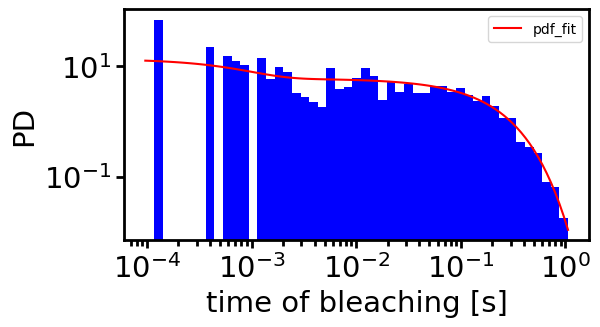

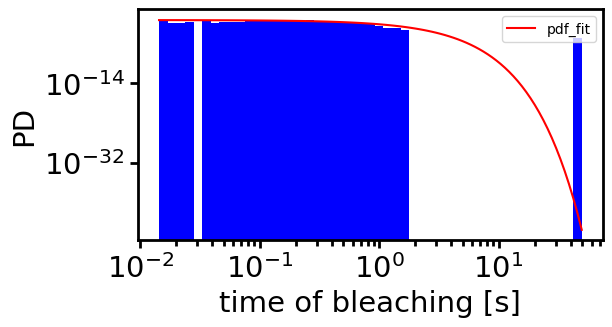

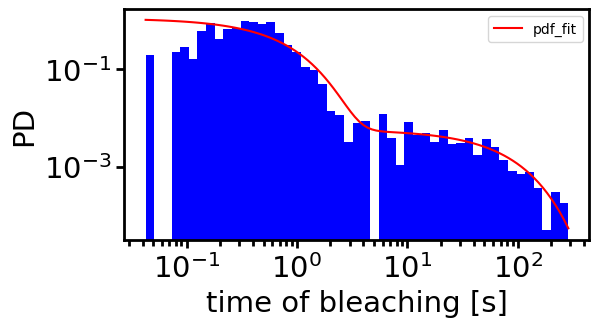

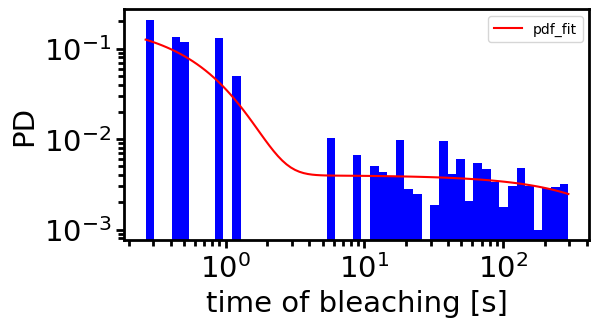

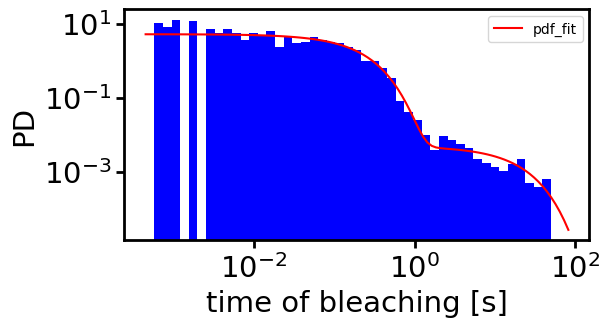

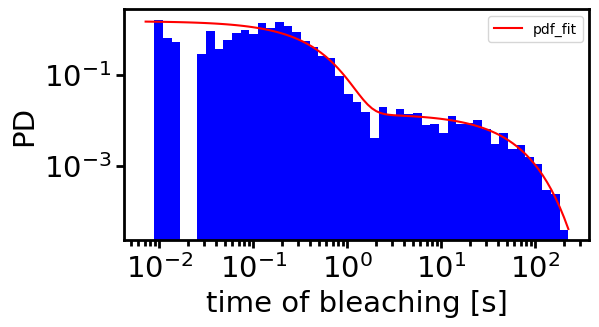

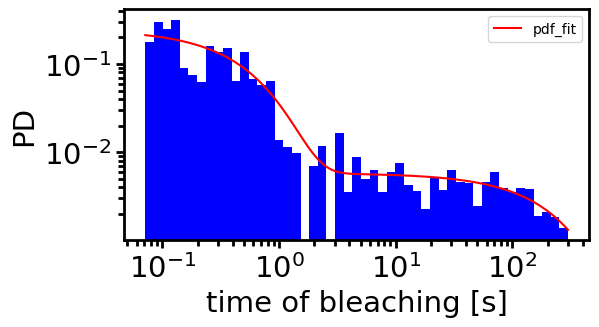

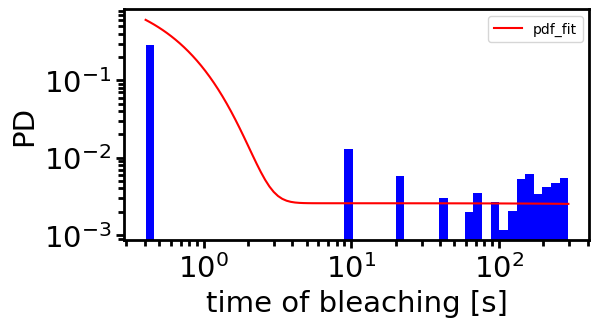

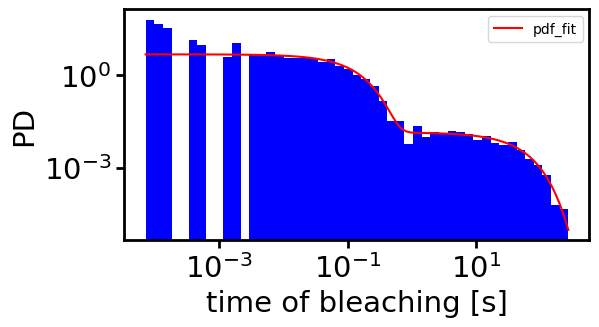

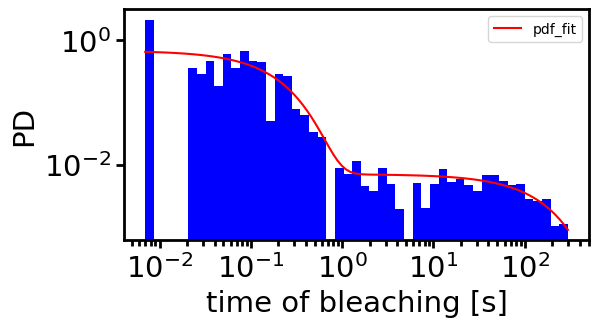

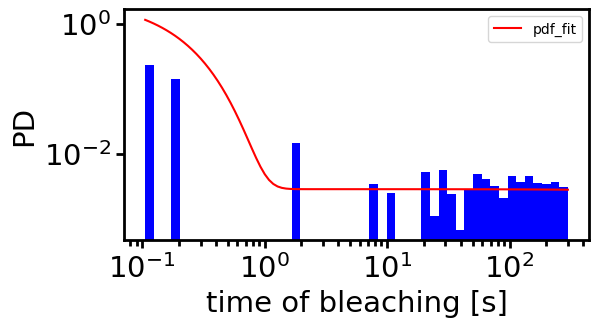

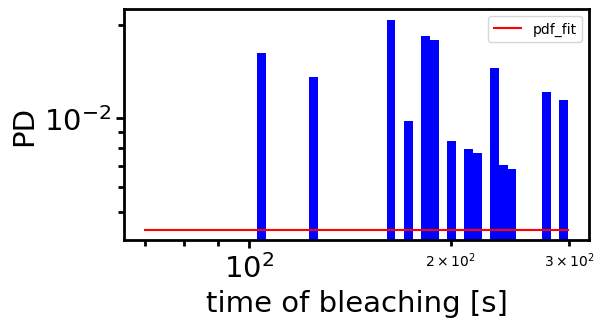

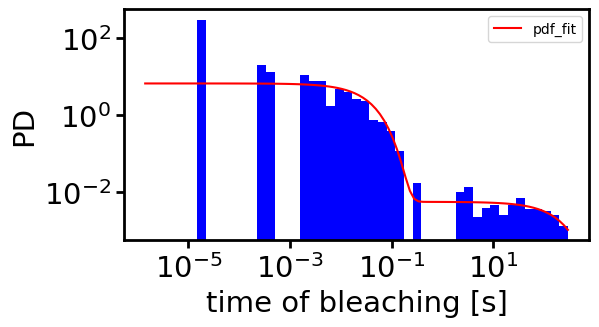

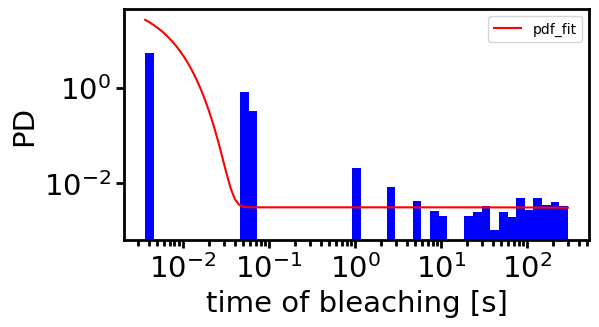

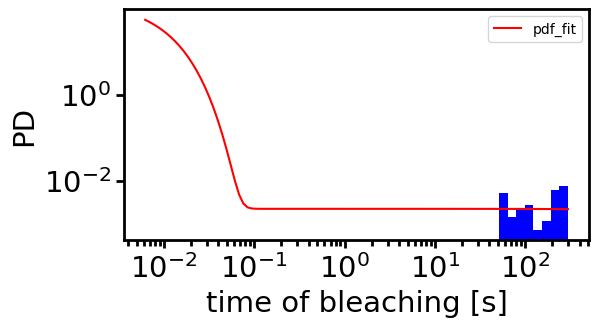

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 600x300 with 1 Axes>

In [4]:
for (bl_times, parameters_1) in zip(bleaching_times_all, parameters_all_fit_pdf):
    for i in range(bl_times.shape[1]):
        pi_fit_1, lambda1_fit_1, lambda2_fit_1 = parameters_1[i]
        #pi_fit_2, lambda1_fit_2, lambda2_fit_2 = parameters_2[i]
        data = bl_times[:, i][~np.isnan(bl_times[:, i])]
        bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
        ax = fi.universal_figure(type_='hist', bins=bins, data=data, density=True) 
        x = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 100)
        # fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1_fit_2, lambda2_fit_2, pi_fit_2)], 
        #                     axes=ax[0], color='orange', label='cdf_fit')
        fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1_fit_1, lambda2_fit_1, pi_fit_1)], 
                            type_='line', axes=ax[0], yscale='log', xscale='log', 
                            xlabel='time of bleaching [s]', ylabel='PD', color='red', label='pdf_fit', legend=True)

In [16]:
parameters_all_fit_pdf

[[[0.005624041482487347, 1330.5761376859432, 5.939389835780024],
  [0.9999552003807377, 2.206850975128578, 130.04647716540273],
  [0.3407652480072196, 0.016185065305678585, 1.6054139256463997],
  [0.0420041191196254, 1.8344615106451239, 0.0016188574598447953]],
 [[0.9242278150991226, 5.5561195435341375, 0.06364558563059565],
  [0.527795421411815, 0.02595348092578773, 3.1100577285293114],
  [0.9111326359308145, 0.004930936275153742, 2.101266126370486],
  [0.9836881127385932, 6.416764321367537e-05, 2.467475787726268]],
 [[0.5200587432809316, 0.026990670303129335, 10.061823014800558],
  [0.8940312862480491, 0.006940389346948249, 5.591890618215751],
  [0.992285684995163, 6.415383207253778e-05, 7.092282524734088],
  [0.9999338930386481, 3.296911113678656e-09, 85459.45141607121]],
 [[0.8189858214696287, 0.005707440174398993, 31.31282539297835],
  [0.9944911951284371, 6.414045441941634e-05, 268.4669229705938],
  [0.9745252424283154, 6.416721434697676e-05, 161.03478040003063],
  [0.99993389303

In [25]:
from scipy.optimize import differential_evolution, LinearConstraint
from sklearn.metrics import r2_score


x_data = np.linspace(0, 300, 300001)
y_data = fingerprints_all[0].values

def objective_function(params):
    y_pred = dist.fit_4_fluorophore(x_data, *params)
    error = np.sum((y_data - y_pred) ** 2)

    return error

bounds = [(0.1, 500), (0.1, 500), (0.1, 500), (0.1, 500), (1e-8, 10), (1e-8, 10), (1e-8, 10), 
(1e-8, 10), (0, 1), (0, 1), (0, 1), (0, 1)]

##### set up constraints

In [26]:
epsilon = 1e-3
linear_constraint1 = LinearConstraint(
    A=[[1, -1, 0, 0,  # lam1_1 > lam2_1 
        0, 0, 0, 0, 
        0, 0, 0, 0,],
        [0, 1, -1, 0,  # lam2_1 > lam3_1
        0, 0, 0, 0, 
        0, 0, 0, 0,],
        [0, 0, 1, -1,  # lam3_1 > lam4_1
        0, 0, 0, 0, 
        0, 0, 0, 0,],
        [-0.1, 0, 0, 0, # lam1_1 > lam1_2
        1, 0, 0, 0, 
        0, 0, 0, 0,],
        [0, -0.1, 0, 0, # lam2_1 > lam2_2
        0, 1, 0, 0, 
        0, 0, 0, 0,],
        [0, 0, -0.1, 0, # lam3_1 > lam3_2
        0, 0, 1, 0, 
        0, 0, 0, 0,],
        [0, 0, 0, -0.1, # lam4_1 > lam4_2
        0, 0, 0, 1, 
        0, 0, 0, 0,],
        [0, 0, 0, 0, # lam1_2 > lam2_2
        1, -1, 0, 0, 
        0, 0, 0, 0,],
        [0, 0, 0, 0, # lam2_2 > lam3_2
        0, 1, -1, 0, 
        0, 0, 0, 0,],
        [0, 0, 0, 0, # lam3_2 > lam4_2
        0, 0, 1, -1, 
        0, 0, 0, 0,],
        [0, 0, 0, 0, # p1 > p2
        0, 0, 0, 0, 
        1, -1, 0, 0,],
        [0, 0, 0, 0, # p2 > p3
        0, 0, 0, 0, 
        0, 1, -1, 0,],
        [0, 0, 0, 0, # p3 > p4
        0, 0, 0, 0, 
        0, 0, 1, -1,]], 
    lb=[epsilon, epsilon, epsilon, -float('inf'), -float('inf'), -float('inf'), -float('inf'), epsilon, epsilon, epsilon, epsilon, epsilon, epsilon], 
    ub=[float('inf'), float('inf'), float('inf'), 0, 0, 0, 0, float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf')])

In [27]:
differential_evolution(objective_function, bounds=bounds, maxiter=1000, popsize=50, disp=True, constraints=linear_constraint1)

differential_evolution step 1: f(x)= inf
differential_evolution step 2: f(x)= inf
differential_evolution step 3: f(x)= inf
differential_evolution step 4: f(x)= 1197.7346257985025
differential_evolution step 5: f(x)= 1197.7346257985025
differential_evolution step 6: f(x)= 1197.7346257985025
differential_evolution step 7: f(x)= 1197.7346257985025
differential_evolution step 8: f(x)= 1166.1367157226705
differential_evolution step 9: f(x)= 1166.1367157226705
differential_evolution step 10: f(x)= 1129.1682367455148
differential_evolution step 11: f(x)= 1129.1682367455148
differential_evolution step 12: f(x)= 1129.1682367455148
differential_evolution step 13: f(x)= 1114.2888428196443
differential_evolution step 14: f(x)= 1114.2888428196443
differential_evolution step 15: f(x)= 1093.482378890375
differential_evolution step 16: f(x)= 1093.482378890375
differential_evolution step 17: f(x)= 1093.482378890375
differential_evolution step 18: f(x)= 1093.482378890375
differential_evolution step 19: 

             message: Maximum number of iterations has been exceeded.
             success: False
                 fun: 0.7830646427898935
                   x: [ 6.375e+00  5.155e+00  4.099e+00  3.722e+00
                        5.783e-01  4.976e-01  2.036e-02  8.151e-04
                        1.000e+00  9.989e-01  6.637e-01  2.325e-03]
                 nit: 1000
                nfev: 77431
          population: [[ 7.066e+00  6.232e+00 ...  6.429e-01  6.266e-01]
                       [ 7.715e+00  6.394e+00 ...  7.044e-01  6.748e-01]
                       ...
                       [ 7.948e+00  6.725e+00 ...  7.195e-01  6.805e-01]
                       [ 8.071e+00  6.583e+00 ...  7.125e-01  7.086e-01]]
 population_energies: [ 7.831e-01  1.256e+00 ...  1.486e+00  1.372e+00]
              constr: [array([ 0.000e+00,  0.000e+00, ...,  0.000e+00,
                              0.000e+00])]
    constr_violation: 0.0
               maxcv: 0.0
                 jac: [array([[ 1.000e+00, -1.

In [1]:
1/0.5

2.0

In [2]:
1/0.02

50.0

In [3]:
1/8e-4

1250.0

In [4]:
1250/50

25.0

In [5]:
50/2

25.0

array([[<Axes: title={'center': 'bleaching rate'}, xlabel='time (s)', ylabel='% emission'>]],
      dtype=object)

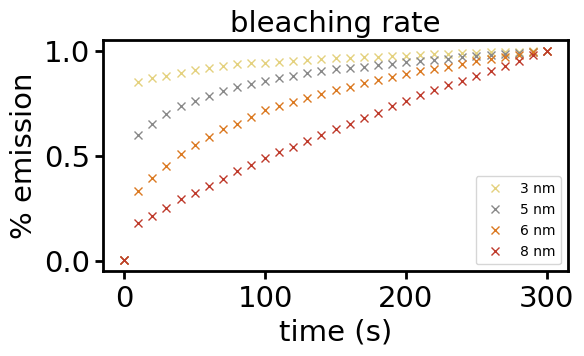

In [6]:
labels = ['3 nm', '5 nm', '6 nm', '8 nm']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(0, 300, 1000)
for (fingerprint, parameters, label, color) in zip(fingerprints_all, parameters_all_fit_pdf, labels, colors):
    #pi, lambda1, lambda2 = parameters
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    #fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(title='bleaching rate', ylabel='% emission', xlabel='time (s)', legend=True, axes=ax[0])

array([[<Axes: title={'center': 'bleaching rate'}, xlabel='time (s)', ylabel='% emission'>]],
      dtype=object)

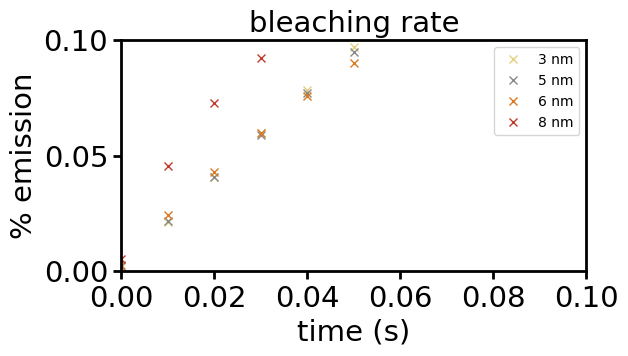

In [13]:
labels = ['3 nm', '5 nm', '6 nm', '8 nm']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(0, 300, 1000)
for (fingerprint, parameters, label, color) in zip(fingerprints_all, parameters_all_fit_pdf, labels, colors):
    #pi, lambda1, lambda2 = parameters
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::10], fingerprint[::10]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::10], fingerprint[::10]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    #fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(title='bleaching rate', ylabel='% emission', xlabel='time (s)', legend=True, axes=ax[0], xlim=[0, 0.1], ylim=[0, 0.1])